<a href="https://colab.research.google.com/github/mssamoilenko/-_optuna/blob/main/%20%D0%A1%D0%B0%D0%BC%D0%BE%D0%B9%D0%BB%D0%B5%D0%BD%D0%BA%D0%BE%D0%94%D0%97_7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [80]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder, StandardScaler, OneHotEncoder

In [40]:
df = pd.read_csv("https://raw.githubusercontent.com/HalyshAnton/IT-Step-Pyton-AI/main/module3/data/House_Rent_Dataset.csv", index_col="Unnamed: 0")

[Інформація про дані](https://www.kaggle.com/datasets/iamsouravbanerjee/house-rent-prediction-dataset)

In [96]:
df.head(20)

,size,furnishing status,city,rent
0,1100.0,Unfurnished,Kolkata,10000.0
1,800.0,Semi-Furnished,Kolkata,20000.0
2,1000.0,Semi-Furnished,Kolkata,17000.0
3,800.0,Unfurnished,Kolkata,10000.0
4,850.0,Unfurnished,Kolkata,7500.0
5,600.0,Unfurnished,Kolkata,7000.0
6,700.0,Unfurnished,Kolkata,10000.0
7,250.0,Unfurnished,NaN,5000.0
8,800.0,Unfurnished,Kolkata,26000.0
9,1000.0,Semi-Furnished,Kolkata,NaN


In [42]:
df = df[['Size', 'Furnishing Status', 'City', 'Rent']]
df.head()

,Size,Furnishing Status,City,Rent
0,1100.0,Unfurnished,Kolkata,10000.0
1,800.0,Semi-Furnished,Kolkata,20000.0
2,1000.0,Semi-Furnished,Kolkata,17000.0
3,800.0,Unfurnished,Kolkata,10000.0
4,850.0,Unfurnished,Kolkata,7500.0


In [43]:
df.columns = df.columns.str.lower()
df.head()

,size,furnishing status,city,rent
0,1100.0,Unfurnished,Kolkata,10000.0
1,800.0,Semi-Furnished,Kolkata,20000.0
2,1000.0,Semi-Furnished,Kolkata,17000.0
3,800.0,Unfurnished,Kolkata,10000.0
4,850.0,Unfurnished,Kolkata,7500.0


# Завдання 1
Очистіть дані від викидів, розділіть на тренувальну та тестову чатини. Цільова ознака `Rent`

In [44]:
df.shape

(4746, 4)

In [45]:
numb_col = df[['size', 'rent']]
numb_col.head()

,size,rent
0,1100.0,10000.0
1,800.0,20000.0
2,1000.0,17000.0
3,800.0,10000.0
4,850.0,7500.0


In [46]:
categ_col = df[['furnishing status', 'city']]
categ_col.head()

,furnishing status,city
0,Unfurnished,Kolkata
1,Semi-Furnished,Kolkata
2,Semi-Furnished,Kolkata
3,Unfurnished,Kolkata
4,Unfurnished,Kolkata


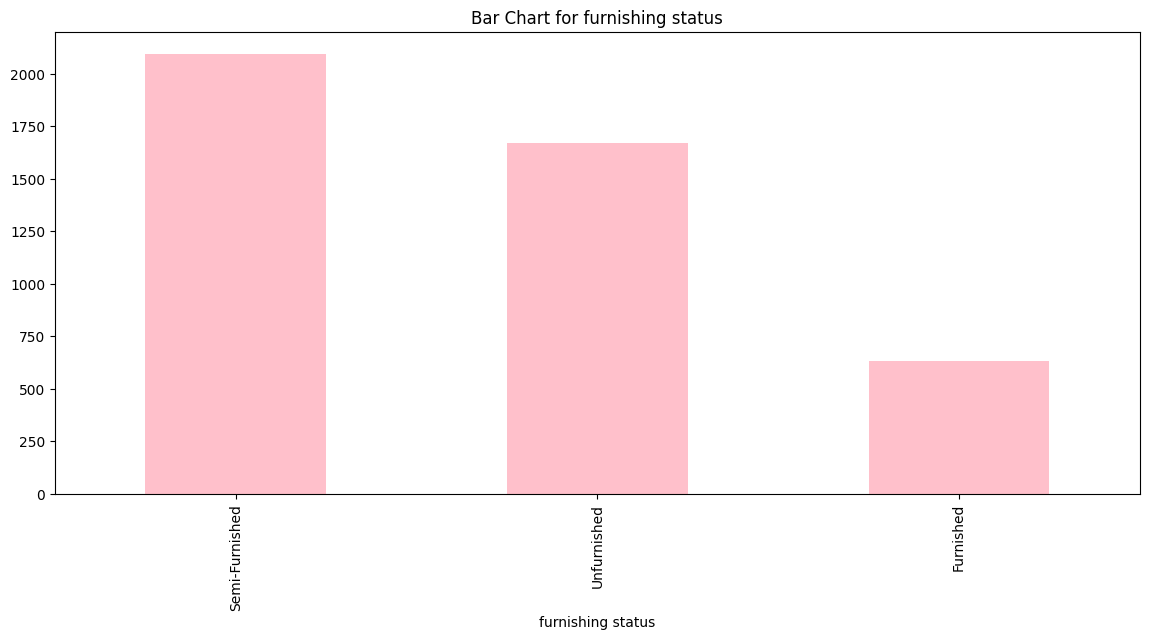

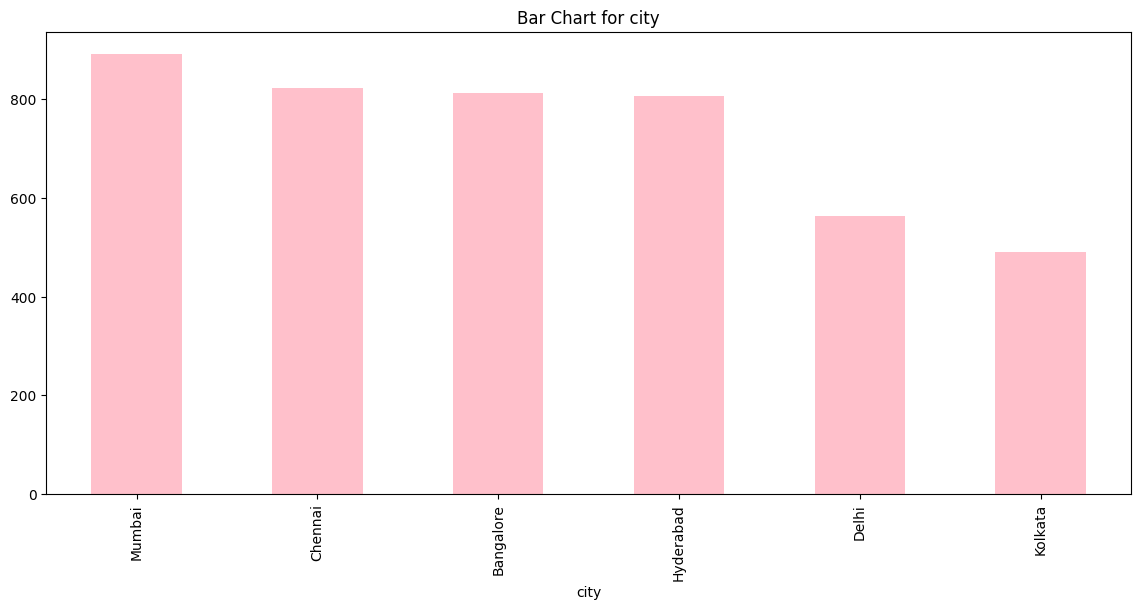

In [47]:
for col in categ_col.columns:
  func_hist = categ_col[col].value_counts().plot(kind='bar', color='pink', figsize=(14,6))
  plt.title(f'Bar Chart for {col}')
  plt.show()

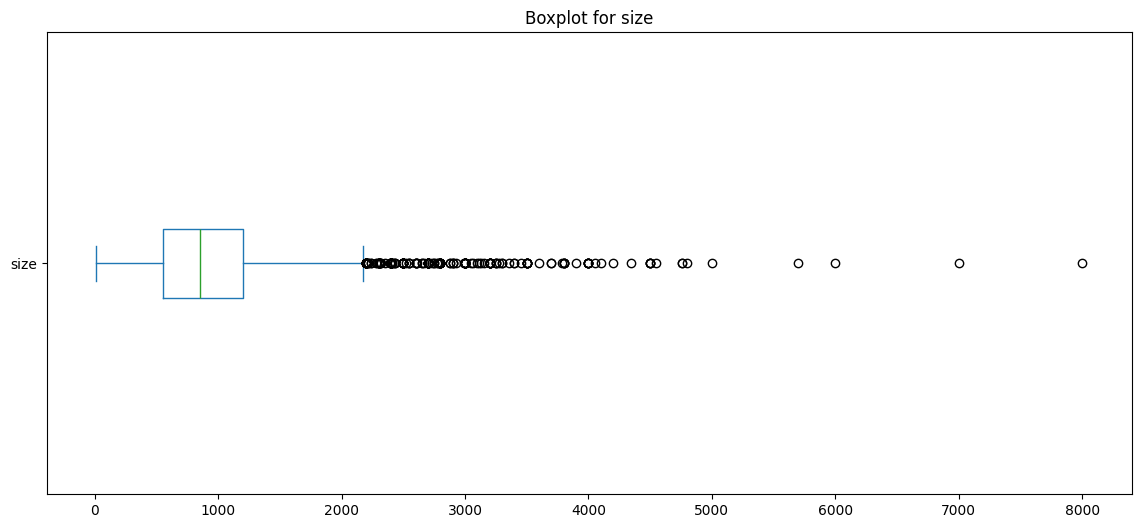

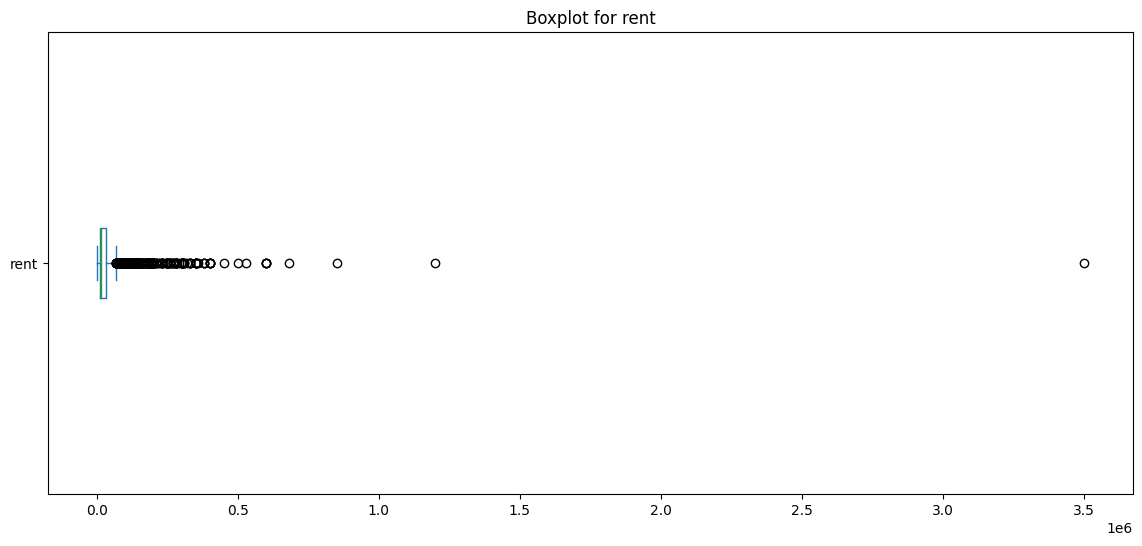

In [48]:
for col in numb_col.columns:
  func_box = numb_col[col].plot(kind='box', vert=False, figsize=(14,6))
  plt.title(f'Boxplot for {col}')
  plt.show()

In [49]:
Q1 = df['rent'].quantile(0.25)
Q3 = df['rent'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df_cleaned = df[(df['rent'] >= lower_bound) & (df['rent'] <= upper_bound)]

df_cleaned

,size,furnishing status,city,rent
0,1100.0,Unfurnished,Kolkata,10000.0
1,800.0,Semi-Furnished,Kolkata,20000.0
2,1000.0,Semi-Furnished,Kolkata,17000.0
3,800.0,Unfurnished,Kolkata,10000.0
4,850.0,Unfurnished,Kolkata,7500.0
...,...,...,...,...
4741,1000.0,Semi-Furnished,Hyderabad,15000.0
4742,2000.0,Semi-Furnished,Hyderabad,29000.0
4743,1750.0,Semi-Furnished,Hyderabad,35000.0
4744,1500.0,Semi-Furnished,Hyderabad,45000.0


In [50]:
df_cleaned.shape

(3895, 4)

In [51]:
numb_col_clean = df_cleaned[['size', 'rent']]
numb_col_clean.head()

,size,rent
0,1100.0,10000.0
1,800.0,20000.0
2,1000.0,17000.0
3,800.0,10000.0
4,850.0,7500.0


In [52]:
categ_col_clean = df_cleaned[['furnishing status', 'city']]
categ_col_clean.head()

,furnishing status,city
0,Unfurnished,Kolkata
1,Semi-Furnished,Kolkata
2,Semi-Furnished,Kolkata
3,Unfurnished,Kolkata
4,Unfurnished,Kolkata


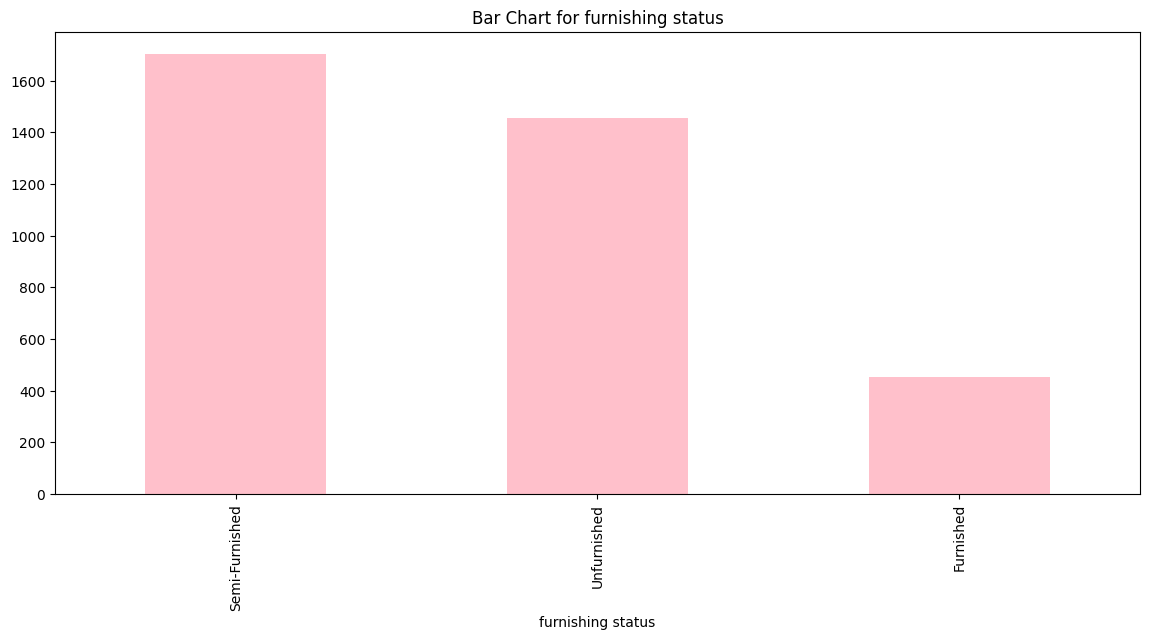

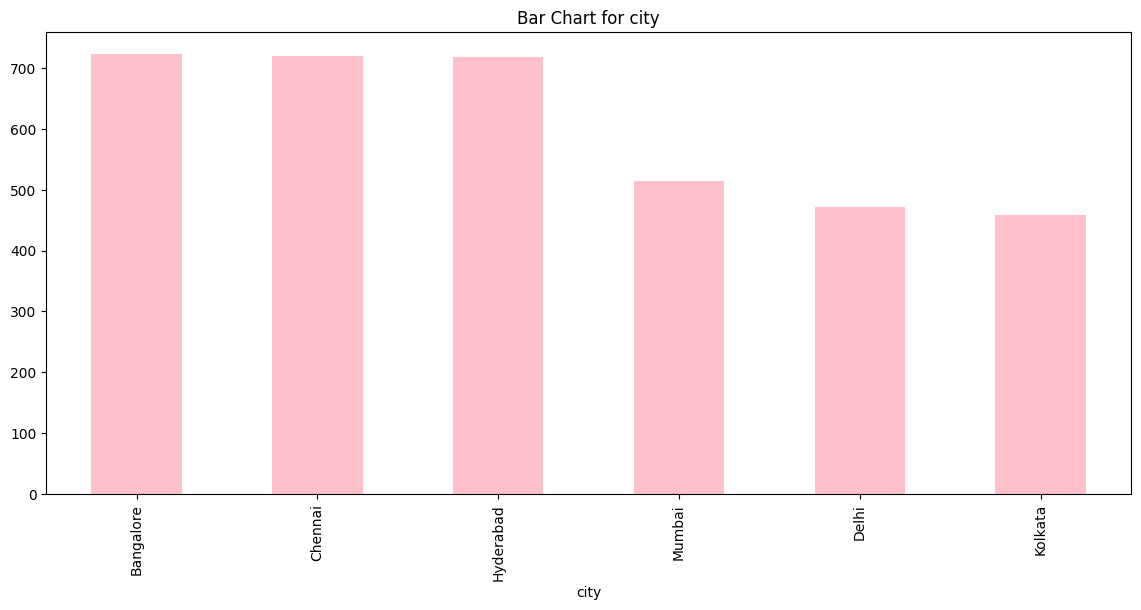

In [53]:
for col in categ_col_clean.columns:
  func_hist = categ_col_clean[col].value_counts().plot(kind='bar', color='pink', figsize=(14,6))
  plt.title(f'Bar Chart for {col}')
  plt.show()

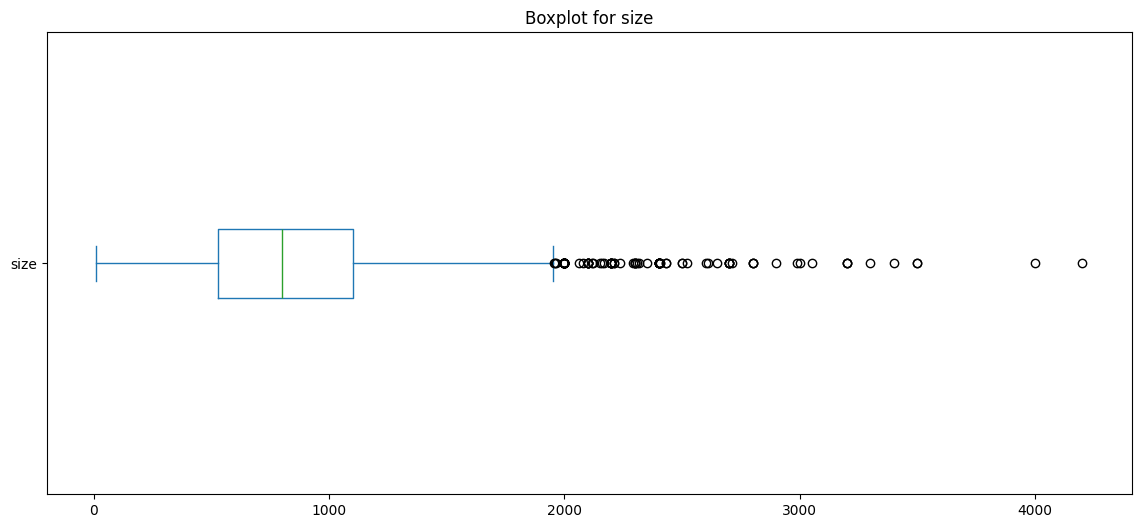

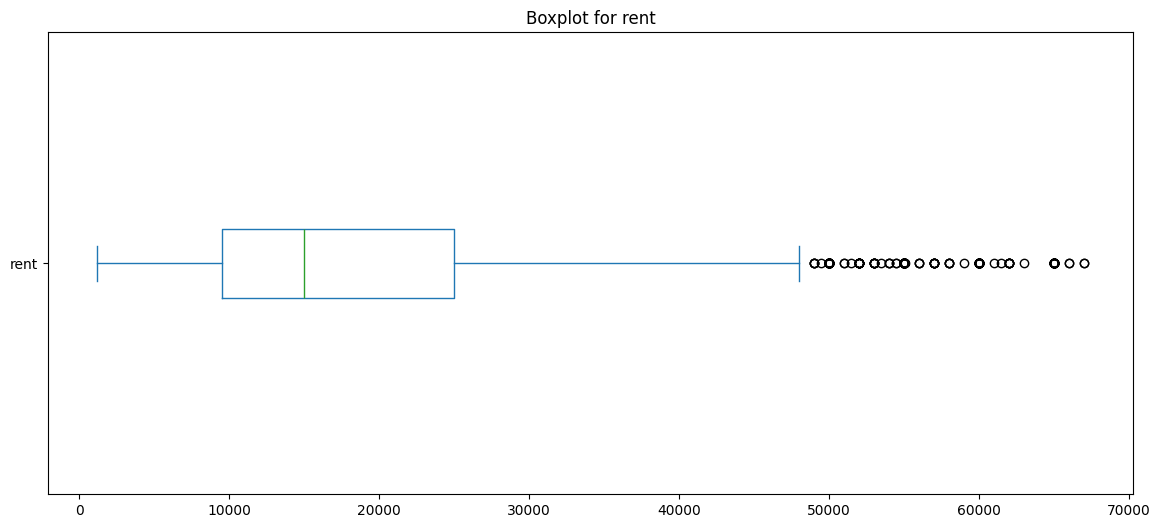

In [54]:
for col in numb_col_clean.columns:
  func_box = numb_col_clean[col].plot(kind='box', vert=False, figsize=(14,6))
  plt.title(f'Boxplot for {col}')
  plt.show()

# Завдання 2
Створіть Pipeline для обробки числових стовпчиків(заповнення пропусків)

In [55]:
numb_col_clean.isna().sum()

,0
size,285
rent,0


In [56]:
y = df_cleaned['rent']
X = df_cleaned[['furnishing status', 'city']]

In [57]:
X_train, X_test, y_train, y_test = train_test_split(X,y, train_size=0.8, random_state=42)

In [58]:
num_columns = X_train.select_dtypes(include='number').columns

In [69]:
num_transformer = Pipeline([('impute', SimpleImputer(strategy='median')), ('scaler', StandardScaler())])

# Завдання 3
Створіть Pipeline для обробки категоріальних стовпчиків(заповнення пропусків та кодування)

In [62]:
categ_col_clean.isna().sum()

,0
furnishing status,283
city,289


In [63]:
cat_columns = X_train.select_dtypes(include='object').columns

In [71]:
cat_transformer = Pipeline([('impute', SimpleImputer(strategy='most_frequent')),('onehot', OneHotEncoder(handle_unknown='ignore'))])

# Завдання 4
Об'єднайте попередні Pipeline в один ColumnTransformer

In [72]:
preprocessor = ColumnTransformer([('num', num_transformer, num_columns), ('cat', cat_transformer, cat_columns)])
preprocessor

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('impute',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 Index([], dtype='object')),
                                ('cat',
                                 Pipeline(steps=[('impute',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehot',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 Index(['furnishing status', 'city'], dtype='object'))])

# Завдання 5
Створіть остаточну модель та натренуйте її

In [73]:
full_model = Pipeline([('prep', preprocessor), ('lin reg', LinearRegression())])
full_model.fit(X_train, y_train)

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index([], dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['furnishing status', 'city'], dtype='object'))])),
                ('lin reg', LinearRegression())])

# Завдання 6
Виведіть основні метрики моделі

In [79]:
y_pred = full_model.predict(X_test)

In [75]:
mae = mean_absolute_error(y_test, y_pred)
mae

8750.988305672081

In [76]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
rmse

12069.461866663076

In [77]:
r2 = r2_score(y_test, y_pred)
r2

0.30921028951385976

# Завдання 7
Спрогнозуйте ціну будинку

In [87]:
data = pd.DataFrame({'Size': [900],
                     'Furnishing Status': ['Semi-Furnished'],
                     'City': ['Mumbai']})

data

,Size,Furnishing Status,City
0,900,Semi-Furnished,Mumbai


In [89]:
data.columns = data.columns.str.lower()
data.head()

,size,furnishing status,city
0,900,Semi-Furnished,Mumbai


In [99]:
predicted_rent = full_model.predict(data)
f"Спрогнозована ціна будинку {predicted_rent[0]:.1f}"

'Спрогнозована ціна будинку 37529.5'